## Download onto Google Colab

In [ ]:
import gdown

# Replace the ID with the actual file ID from Google Drive link
#file_id = "1cd2g_6jt7Ccnv8IVNQdFL_jmVn4lep-n"
file_id_grey = "1jeOKBDQZgluJtqJYhz7P4XFun5d4mV-a"
gdown.download(f"https://drive.google.com/uc?id={file_id_grey}", "coins.jpg", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1jeOKBDQZgluJtqJYhz7P4XFun5d4mV-a
To: /content/coins.jpg
100%|██████████| 48.9k/48.9k [00:00<00:00, 38.9MB/s]


'coins.jpg'

#LAB 2

Coins - min: 17 max: 103
Coins - min: 0 max: 255
Coins - Τυπική απόκλιση πριν: 24.196825738587506 μετά: 71.77095879625517


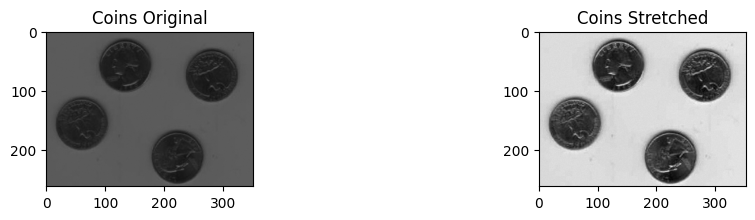

In [ ]:
# Εγκατάσταση και εισαγωγή βιβλιοθηκών
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Συνάρτηση για Άσκηση 1: Ενίσχυση αντίθεσης
def contrast_stretching(img):
    """
    Εφαρμόζει γραμμικό μετασχηματισμό στην εικόνα:
    I' = (I - min(I)) * (255 / (max(I) - min(I)))
    """

    img = img.astype(np.float32)
    min_val = np.min(img)
    max_val = np.max(img)
    stretched = (img - min_val) * (255.0 / (max_val - min_val))


    return stretched.astype(np.uint8)

# Συνάρτηση για υπολογισμό τυπικής απόκλισης
def compute_std(img):
    return np.std(img)

# Ανάγνωση και επεξεργασία εικόνων για Άσκηση 1
# Βεβαιωθείτε ότι τα αρχεία 'coins.jpg' και 'pout.tif' βρίσκονται στο κατάλληλο path
img_coins = cv2.imread('coins.jpg', cv2.IMREAD_GRAYSCALE)

# Έλεγχος φόρτωσης εικόνων
if img_coins is None:
    print("Έλεγχος: Μία ή και οι δύο εικόνες δεν βρέθηκαν. Βεβαιωθείτε ότι τα αρχεία υπάρχουν.")
else:
    # Εφαρμογή μετασχηματισμού
    coins_stretched = contrast_stretching(img_coins)
    print("Coins - min:", np.min(img_coins), "max:", np.max(img_coins))
    print("Coins - min:", np.min(coins_stretched), "max:", np.max(coins_stretched))
    #print("Pout - min:", np.min(img_pout), "max:", np.max(img_pout))
    # Υπολογισμός τυπικής απόκλισης
    std_coins_before = compute_std(img_coins)
    std_coins_after = compute_std(coins_stretched)

    print("Coins - Τυπική απόκλιση πριν:", std_coins_before, "μετά:", std_coins_after)

    # Εμφάνιση εικόνων (προαιρετικά)
    plt.figure(figsize=(10,4))
    plt.subplot(2,2,1), plt.imshow(img_coins,cmap='gray', vmin=0, vmax=255), plt.title('Coins Original')
    plt.subplot(2,2,2), plt.imshow(coins_stretched, cmap='gray'), plt.title('Coins Stretched')
    plt.tight_layout()
    plt.show()

Histogram Computation


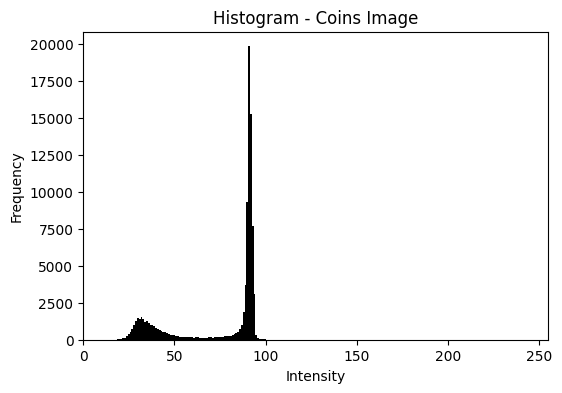

In [ ]:
def myhist(image):
    """
    Δημιουργεί και επιστρέφει το ιστογράμμα μιας ασπρόμαυρης εικόνας χρησιμοποιώντας διπλούς βρόχους.
    Δηλαδή, για κάθε pixel της εικόνας με τιμή από 0 έως 255, αυξάνει την αντίστοιχη καταμέτρηση στο πίνακα histogram.
    """
    # Αρχικοποίηση του histogram με 256 μηδενικά στοιχεία
    histogram = [0] * 256
    # Λήψη διαστάσεων εικόνας
    rows, cols = image.shape
    # Διπλοί βρόχοι για κάθε στοιχείο της εικόνας
    for i in range(rows):
        for j in range(cols):
            # Ανάγνωση τιμής pixel (0 έως 255)
            pixel_value = image[i, j]
            # Ενημέρωση του histogram
            histogram[pixel_value] += 1
    return histogram
if img_coins is not None:
    hist_coins = myhist(img_coins)
    plt.figure(figsize=(6,4))
    plt.bar(np.arange(256), hist_coins, width=1.0, color='black')
    plt.title("Histogram - Coins Image")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.xlim([0,255])
    plt.show()

### Εμφάνιση βασικών πληροφοριών
##### shape: (height, width, channels)
##### dtype: ο τύπος των δεδομένων (π.χ. uint8)
##### size: ο συνολικός αριθμός pixels (height * width * channels)

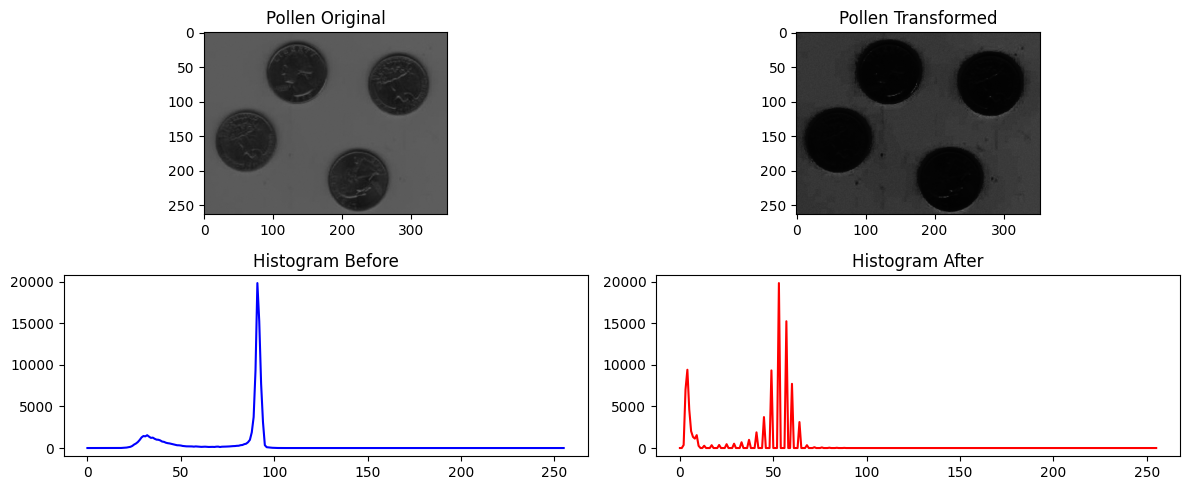

In [ ]:
# Συνάρτηση για Άσκηση 4: Τμηματικός Μετασχηματισμός
def piecewise_transform(img, r1, s1, r2, s2):
    """
    Εφαρμόζει τμηματικό μετασχηματισμό:
    - f ∈ [0, r1]      : γραμμική χαρτογράφηση από 0 σε s1
    - f ∈ (r1, r2]     : γραμμική χαρτογράφηση από s1 σε s2
    - f ∈ (r2, 255]    : γραμμική χαρτογράφηση από s2 σε 255
    """
    img = img.astype(np.float32)
    result = np.zeros_like(img)

    # Περιοχή 1: [0, r1]
    idx1 = img <= r1
    result[idx1] = (s1 / r1) * img[idx1]

    # Περιοχή 2: (r1, r2]
    idx2 = (img > r1) & (img <= r2)
    result[idx2] = s1 + ((s2 - s1) / (r2 - r1)) * (img[idx2] - r1)

    # Περιοχή 3: (r2, 255]
    idx3 = img > r2
    result[idx3] = s2 + ((255 - s2) / (255 - r2)) * (img[idx3] - r2)

    return np.clip(result, 0, 255).astype(np.uint8)

# Ανάγνωση εικόνας pollen.jpg
#img_pollen = cv2.imread('pollen.jpg', cv2.IMREAD_GRAYSCALE)
img_pollen = img_coins
if img_pollen is None:
    print("Η εικόνα 'pollen.jpg' δεν βρέθηκε. Βεβαιωθείτε ότι το αρχείο υπάρχει.")
else:
    # Εφαρμογή τμηματικού μετασχηματισμού με τις παραμέτρους
    r1, s1, r2, s2 = 80, 10, 140, 245
    pollen_trans = piecewise_transform(img_pollen, r1, s1, r2, s2)

    # Εμφάνιση ιστογραμμάτων πριν και μετά
    hist_before = myhist(img_pollen)
    hist_after = myhist(pollen_trans)

    plt.figure(figsize=(12,5))
    plt.subplot(2,2,1), plt.imshow(img_pollen, cmap='gray', vmin=0, vmax=255), plt.title('Pollen Original')
    plt.subplot(2,2,2), plt.imshow(pollen_trans, cmap='gray', vmin=0, vmax=255), plt.title('Pollen Transformed')
    plt.subplot(2,2,3), plt.plot(hist_before, color='blue'), plt.title('Histogram Before')
    plt.subplot(2,2,4), plt.plot(hist_after, color='red'), plt.title('Histogram After')
    plt.tight_layout()
    plt.show()